# **Project 3: CBTTC Pediatric Brain Tumor Classification**
## **Predicting Tumor Grade from CBTTC Proteomic Profiles**
This notebook is a starter project built around the Children's Brain Tumor Tissue Consortium (CBTTC) data in the Proteomic Data Commons (PDC). The baseline project uses the open-access study `PDC000180` and frames the assignment as a logistic regression classification task.

**Research question:** Can proteomic features from the CBTTC pediatric brain tumor study classify tumors into low-grade versus high-grade groups on test data?
Does tumor grade vary by primary diagnosis? Do high-grade and low-grade tumors show different proteomic expression patterns?

# **Abstract**
Childhood brain tumors are among the most serious forms of pediatric cancer, so improving molecular understanding of these tumors is important for diagnosis and treatment planning. This project uses the Children's Brain Tumor Tissue Consortium (CBTTC) proteomic data available through the Proteomic Data Commons to study whether tumor grade can be predicted from protein-expression measurements. The workflow downloads public study data, cleans and merges the clinical and proteomic tables, handles missing values, standardizes the numeric predictors, and trains a logistic regression classification model. Model performance is evaluated with accuracy, precision, recall, F1-score, and ROC-AUC on a held-out test set, along with supporting visualizations. The broader impact of this work is that reproducible analysis of public pediatric cancer data can help identify molecular patterns associated with more aggressive disease.


# **Introduction of the Data Set and Variables**
The dataset used in this project comes from the **Children's Brain Tumor Tissue Consortium (CBTTC)**, a collaborative pediatric brain tumor research effort focused on identifying therapies for children with brain tumors. The data are available through the NCI Cancer Research Data Commons and the Proteomic Data Commons (PDC). For this project starter, the selected PDC study is `PDC000180`, labeled **Pediatric Brain Cancer Pilot Study - Proteome**.

This study is connected to the pediatric brain cancer proteogenomic analysis published by Petralia et al. (2020). Tumor samples were collected through the CBTTC and analyzed with mass-spectrometry-based proteomics, making the dataset suitable for a supervised machine-learning classification task. The modeling table in this notebook combines clinical metadata with protein abundance values, then uses tumor grade as the categorical target variable.

**Sources**
- CBTTC / CRDC dataset listing: https://datacommons.cancer.gov/explore/datasets
- PDC study page: https://pdc.cancer.gov/pdc/study/PDC000180
- Petralia F. et al. (2020), *Integrated Proteogenomic Characterization across Major Histological Types of Pediatric Brain Cancer*: https://pmc.ncbi.nlm.nih.gov/articles/PMC8143193/


In [59]:
# Import the libraries used in this notebook.
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", palette="deep")


In [60]:
# Define the study ID and cache paths.
PDC_STUDY_ID = "PDC000180"
DATA_TYPE = "log2_ratio"
API_URL = "https://pdc.cancer.gov/graphql"

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
proteome_cache = data_dir / f"{PDC_STUDY_ID}_proteome.csv"
clinical_cache = data_dir / f"{PDC_STUDY_ID}_clinical.csv"


def query_pdc(query: str) -> dict:
    # Send a GraphQL query to the Proteomic Data Commons API.
    response = requests.post(API_URL, json={"query": query}, timeout=120)
    response.raise_for_status()
    payload = response.json()
    if "errors" in payload:
        raise ValueError(payload["errors"])
    return payload["data"]


def matrix_to_wide_df(matrix: list) -> pd.DataFrame:
    # Convert the PDC quantitation matrix into a gene-by-sample DataFrame.
    df = pd.DataFrame(matrix[1:], columns=matrix[0]).set_index(matrix[0][0])
    df = df.apply(pd.to_numeric, errors="coerce")
    df.columns = [str(col).split(":")[-1] for col in df.columns]
    return df.sort_index(axis=1)


def records_to_df(records) -> pd.DataFrame:
    # Convert an API record payload into a pandas DataFrame.
    if isinstance(records, list) and records and isinstance(records[0], dict):
        return pd.DataFrame(records)
    if isinstance(records, list) and records and isinstance(records[0], list):
        return pd.DataFrame(records[1:], columns=records[0])
    return pd.DataFrame(records)


def build_quant_query(study_id: str, data_type: str) -> str:
    return "\n".join(
        [
            "{",
            "    quantDataMatrix(",
            f'        pdc_study_id: "{study_id}"',
            f'        data_type: "{data_type}"',
            "        acceptDUA: true",
            "    )",
            "}",
        ]
    )


def build_clinical_query(study_id: str) -> str:
    return "\n".join(
        [
            "{",
            f'    clinicalMetadata(pdc_study_id: "{study_id}" acceptDUA: true) {{',
            "        aliquot_submitter_id",
            "        morphology",
            "        primary_diagnosis",
            "        tumor_grade",
            "        tumor_stage",
            "    }",
            "}",
        ]
    )


def map_grade_group(value):
    # Map detailed grade labels into low-grade and high-grade groups.
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    high_tokens = ["high", "grade iii", "grade iv", "grade 3", "grade 4", "g3", "g4"]
    low_tokens = ["low", "grade ii", "grade i", "grade 2", "grade 1", "g1", "g2"]

    if any(token in text for token in high_tokens):
        return "High Grade"
    if any(token in text for token in low_tokens):
        return "Low Grade"
    return np.nan


In [61]:
# Download the CBTTC proteomic matrix and clinical metadata, or use cached files if they already exist.
if proteome_cache.exists() and clinical_cache.exists():
    proteome_wide = pd.read_csv(proteome_cache, index_col=0)
    clinical_df = pd.read_csv(clinical_cache)
else:
    proteome_response = query_pdc(build_quant_query(PDC_STUDY_ID, DATA_TYPE))
    clinical_response = query_pdc(build_clinical_query(PDC_STUDY_ID))

    proteome_wide = matrix_to_wide_df(proteome_response["quantDataMatrix"])
    clinical_df = records_to_df(clinical_response["clinicalMetadata"])

    proteome_wide.to_csv(proteome_cache)
    clinical_df.to_csv(clinical_cache, index=False)

print("Proteome matrix shape (proteins x samples):", proteome_wide.shape)
print("Clinical metadata shape:", clinical_df.shape)

display(clinical_df.head())
display(proteome_wide.iloc[:5, :5])


Proteome matrix shape (proteins x samples): (7154, 230)
Clinical metadata shape: (293, 5)


,aliquot_submitter_id,morphology,primary_diagnosis,tumor_grade,tumor_stage
0,7316-324,9505/1,"Ganglioglioma, NOS",G1,Unknown
1,7316-445,9380/3,"Glioma, malignant",High Grade,Unknown
2,7316-445,9380/3,"Glioma, malignant",High Grade,Unknown
3,7316-329,9400/3,"Glioma, NOS",G1,Unknown
4,7316-206,9400/3,"Glioma, NOS",G1,Unknown


,7316-101,7316-109,7316-111,7316-114,7316-117
Gene/Aliquot,,,,,
A1BG,-1.7408,-0.7403,-0.3692,0.9485,-0.0447
A2M,-1.0443,-0.7829,-0.3893,0.1037,0.0394
AAAS,NaN,NaN,NaN,-0.2482,-0.6455
AACS,0.1790,0.4741,NaN,-0.0699,NaN
AADAT,NaN,NaN,NaN,NaN,NaN


In [62]:
# Display the dataset shape and the data types of the clinical variables.
clinical_df = clinical_df.drop_duplicates(subset="aliquot_submitter_id").copy()

dataset_overview = pd.DataFrame(
    {
        "Table": ["Clinical metadata", "Proteome matrix"],
        "Rows": [clinical_df.shape[0], proteome_wide.shape[0]],
        "Columns": [clinical_df.shape[1], proteome_wide.shape[1]],
    }
)

clinical_dtypes = pd.DataFrame(
    {
        "Variable": clinical_df.columns,
        "Data Type": clinical_df.dtypes.astype(str).values,
    }
)

display(dataset_overview)
display(clinical_dtypes)
print("Proteomic data types:", proteome_wide.dtypes.unique())


,Table,Rows,Columns
0,Clinical metadata,227,5
1,Proteome matrix,7154,230


,Variable,Data Type
0,aliquot_submitter_id,object
1,morphology,object
2,primary_diagnosis,object
3,tumor_grade,object
4,tumor_stage,object


Proteomic data types: [dtype('float64')]


# **Data Cleaning and Preprocessing**
The steps below align the clinical and proteomic data by sample ID, remove duplicates, inspect missing values, convert the categorical target into a binary outcome, and prepare a modeling table for classification.


In [63]:
# Convert the proteome matrix so that each row is one tumor sample, then merge with clinical metadata.
proteome_by_sample = proteome_wide.T.copy()
proteome_by_sample.index.name = "aliquot_submitter_id"

merged_df = clinical_df.merge(
    proteome_by_sample,
    left_on="aliquot_submitter_id",
    right_index=True,
    how="inner",
)

merged_df["grade_group"] = merged_df["tumor_grade"].apply(map_grade_group)
model_df = merged_df.dropna(subset=["grade_group"]).copy()

clinical_columns = [
    "aliquot_submitter_id",
    "morphology",
    "primary_diagnosis",
    "tumor_grade",
    "tumor_stage",
    "grade_group",
]
protein_columns = [col for col in model_df.columns if col not in clinical_columns]

missing_summary = model_df.isna().sum().sort_values(ascending=False)
protein_missing_rate = model_df[protein_columns].isna().mean().sort_values(ascending=False)
kept_proteins = protein_missing_rate[protein_missing_rate <= 0.20].index.tolist()

encoded_metadata = pd.get_dummies(
    model_df[["morphology", "primary_diagnosis", "tumor_stage"]],
    dummy_na=True,
    drop_first=False,
)

print("Merged table shape:", model_df.shape)
print("Protein features before filtering:", len(protein_columns))
print("Protein features kept for modeling:", len(kept_proteins))
print("\nTarget distribution:")
print(model_df["grade_group"].value_counts())

display(missing_summary.head(10).to_frame("missing_values"))
display(encoded_metadata.head())
display(model_df[clinical_columns].head())


Merged table shape: (218, 7160)
Protein features before filtering: 7154
Protein features kept for modeling: 4958

Target distribution:
grade_group
Low Grade     159
High Grade     59
Name: count, dtype: int64


,missing_values
PRR4,210
DHRS2,209
CILP,208
RCAN3,199
PNMT,199
IMPG1,198
MMP10,198
RSPH14,194
IZUMO1,193
PIWIL2,192


,morphology_9350/1,morphology_9380/3,morphology_9391/3,morphology_9400/3,morphology_9470/3,morphology_9505/1,morphology_9508/3,morphology_nan,primary_diagnosis_Atypical teratoid/rhabdoid tumor,primary_diagnosis_Craniopharyngioma,"primary_diagnosis_Ependymoma, NOS","primary_diagnosis_Ganglioglioma, NOS","primary_diagnosis_Glioma, NOS","primary_diagnosis_Glioma, malignant","primary_diagnosis_Medulloblastoma, NOS",primary_diagnosis_nan,tumor_stage_Unknown,tumor_stage_nan
0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False
1,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False
3,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
4,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
5,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False


,aliquot_submitter_id,morphology,primary_diagnosis,tumor_grade,tumor_stage,grade_group
0,7316-324,9505/1,"Ganglioglioma, NOS",G1,Unknown,Low Grade
1,7316-445,9380/3,"Glioma, malignant",High Grade,Unknown,High Grade
3,7316-329,9400/3,"Glioma, NOS",G1,Unknown,Low Grade
4,7316-206,9400/3,"Glioma, NOS",G1,Unknown,Low Grade
5,7316-207,9400/3,"Glioma, NOS",G1,Unknown,Low Grade


# **Visualization**
These plots summarize the target balance, the most common diagnoses, reduced-dimension proteomic structure, and the most variable proteins in the CBTTC modeling subset.


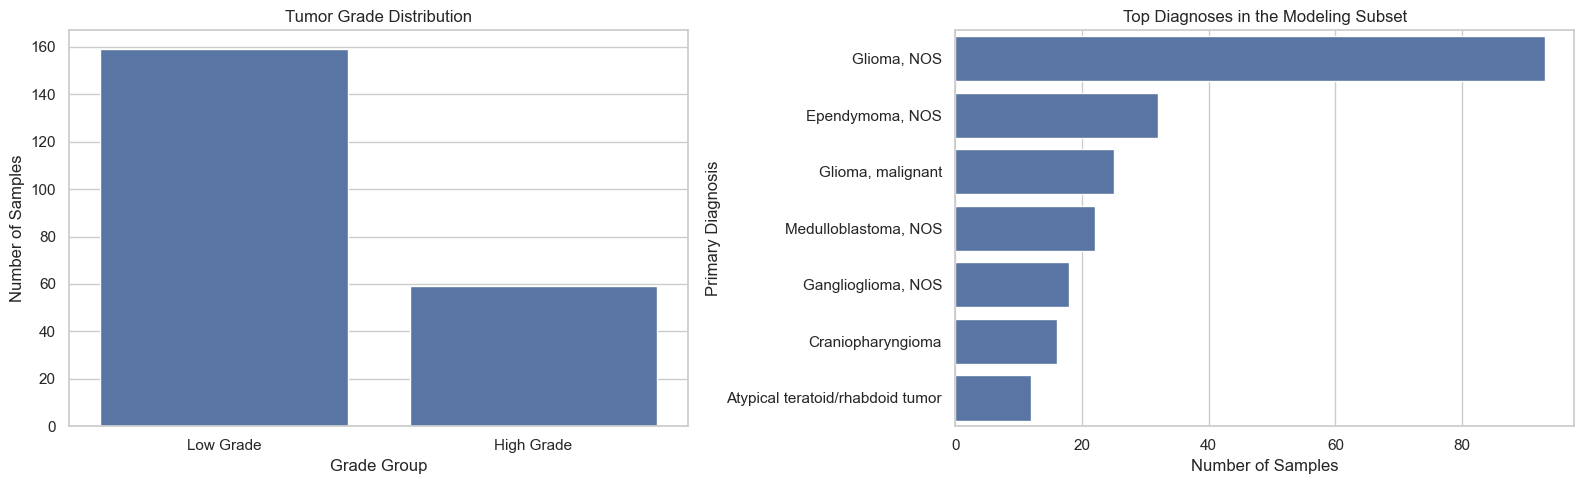

In [64]:
# Plot class balance and the most frequent diagnoses.
viz_df = model_df.copy()
viz_df["primary_diagnosis"] = viz_df["primary_diagnosis"].fillna("Unknown")
top_diagnoses = viz_df["primary_diagnosis"].value_counts().head(10).index

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(
    data=model_df,
    x="grade_group",
    order=model_df["grade_group"].value_counts().index,
    ax=axes[0],
)
axes[0].set_title("Tumor Grade Distribution")
axes[0].set_xlabel("Grade Group")
axes[0].set_ylabel("Number of Samples")

sns.countplot(
    data=viz_df[viz_df["primary_diagnosis"].isin(top_diagnoses)],
    y="primary_diagnosis",
    order=viz_df["primary_diagnosis"].value_counts().head(10).index,
    ax=axes[1],
)
axes[1].set_title("Top Diagnoses in the Modeling Subset")
axes[1].set_xlabel("Number of Samples")
axes[1].set_ylabel("Primary Diagnosis")

plt.tight_layout()
plt.show()


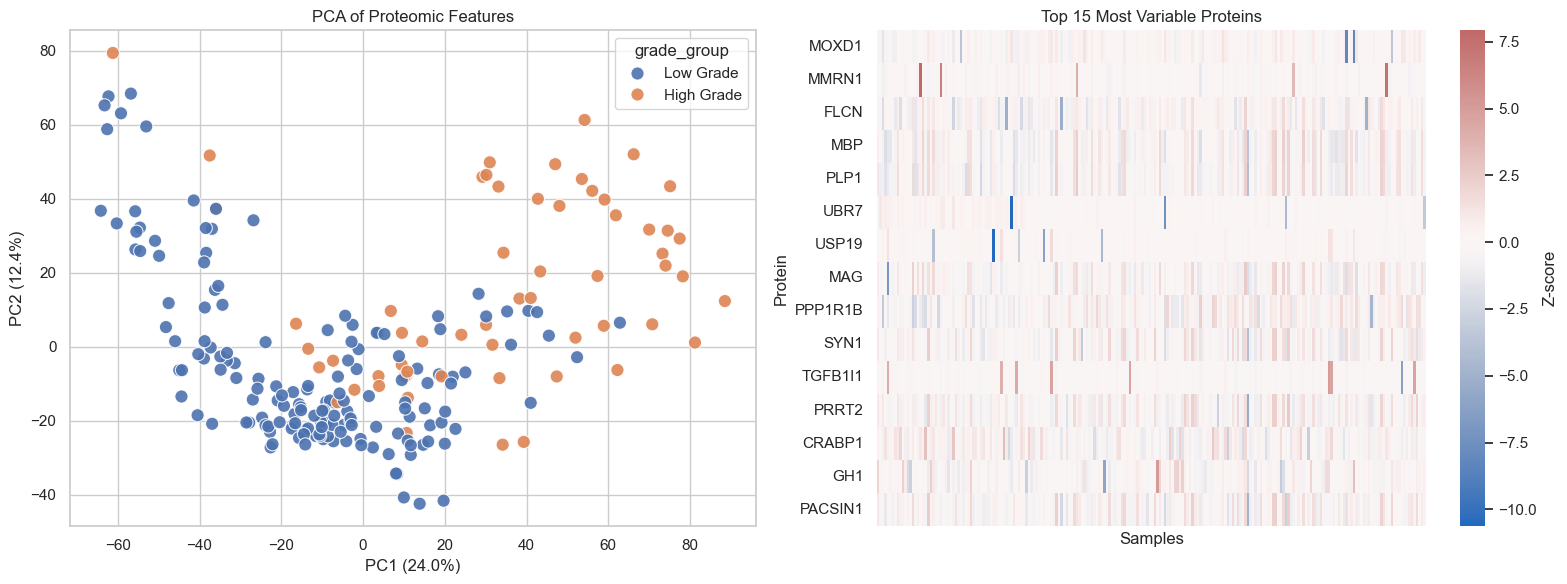

In [65]:
# Visualize the proteomic data with PCA and a heatmap of the most variable proteins.
viz_features = model_df[kept_proteins].copy()
viz_imputed = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(viz_features),
    columns=kept_proteins,
    index=model_df.index,
)
viz_scaled = StandardScaler().fit_transform(viz_imputed)

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(viz_scaled)
pca_df = pd.DataFrame(components, columns=["PC1", "PC2"], index=model_df.index)
pca_df["grade_group"] = model_df["grade_group"].values

top_variable_proteins = viz_imputed.var().sort_values(ascending=False).head(15).index.tolist()
heatmap_df = viz_imputed[top_variable_proteins].copy()
heatmap_df["grade_group"] = model_df["grade_group"].values
heatmap_df = heatmap_df.sort_values("grade_group").drop(columns="grade_group")
heatmap_df = (heatmap_df - heatmap_df.mean()) / heatmap_df.std(ddof=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="grade_group",
    s=90,
    alpha=0.9,
    ax=axes[0],
)
axes[0].set_title("PCA of Proteomic Features")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

sns.heatmap(
    heatmap_df.T,
    cmap="vlag",
    center=0,
    xticklabels=False,
    cbar_kws={"label": "Z-score"},
    ax=axes[1],
)
axes[1].set_title("Top 15 Most Variable Proteins")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Protein")

plt.tight_layout()
plt.show()


## Research Question #2, Does tumor grade vary by primary diagnosis?

In [66]:
# read file, clinical
df = pd.read_csv("PDC000180_clinical(in).csv")
df.head()

,aliquot_submitter_id,morphology,primary_diagnosis,tumor_grade,tumor_stage
0,7316-324,9505/1,"Ganglioglioma, NOS",G1,Unknown
1,7316-445,9380/3,"Glioma, malignant",High Grade,Unknown
2,7316-445,9380/3,"Glioma, malignant",High Grade,Unknown
3,7316-329,9400/3,"Glioma, NOS",G1,Unknown
4,7316-206,9400/3,"Glioma, NOS",G1,Unknown


In [67]:
# show info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   aliquot_submitter_id  293 non-null    object
 1   morphology            293 non-null    object
 2   primary_diagnosis     293 non-null    object
 3   tumor_grade           293 non-null    object
 4   tumor_stage           293 non-null    object
dtypes: object(5)
memory usage: 11.6+ KB


In [68]:
# read file: proteome
df = pd.read_csv("PDC000180_proteome(in).csv")
df.head()

,Gene/Aliquot,7316-101,7316-109,7316-111,7316-114,7316-117,7316-119,7316-120,7316-121.1,7316-121.2,...,7316-937,7316-938,7316-942,7316-944,7316-946,7316-949,7316-952,7316-954,7316-957,7316-99
0,A1BG,-1.7408,-0.7403,-0.3692,0.9485,-0.0447,1.0001,-0.7616,1.5691,1.6101,...,-2.7996,0.5188,1.5583,0.9519,0.9805,-0.4858,-0.9984,1.0759,1.9040,-0.8037
1,A2M,-1.0443,-0.7829,-0.3893,0.1037,0.0394,-0.4928,-0.7111,0.2410,0.3285,...,-1.9508,0.8906,1.9061,-0.3211,0.5017,-0.4224,-0.4007,0.0586,0.9796,-0.2757
2,AAAS,NaN,NaN,NaN,-0.2482,-0.6455,NaN,-1.1472,0.0826,NaN,...,0.8670,NaN,0.0831,-0.3943,-0.0294,0.0821,NaN,-0.0088,-0.0159,0.7892
3,AACS,0.1790,0.4741,NaN,-0.0699,NaN,-0.1300,0.5614,NaN,-0.0932,...,0.4670,NaN,0.5585,-0.5479,-0.3623,-0.6880,NaN,-1.0889,-1.0220,0.8644
4,AADAT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.2920,-4.4450,2.4086


In [69]:
# show info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7154 entries, 0 to 7153
Columns: 231 entries, Gene/Aliquot to 7316-99
dtypes: float64(230), object(1)
memory usage: 12.6+ MB


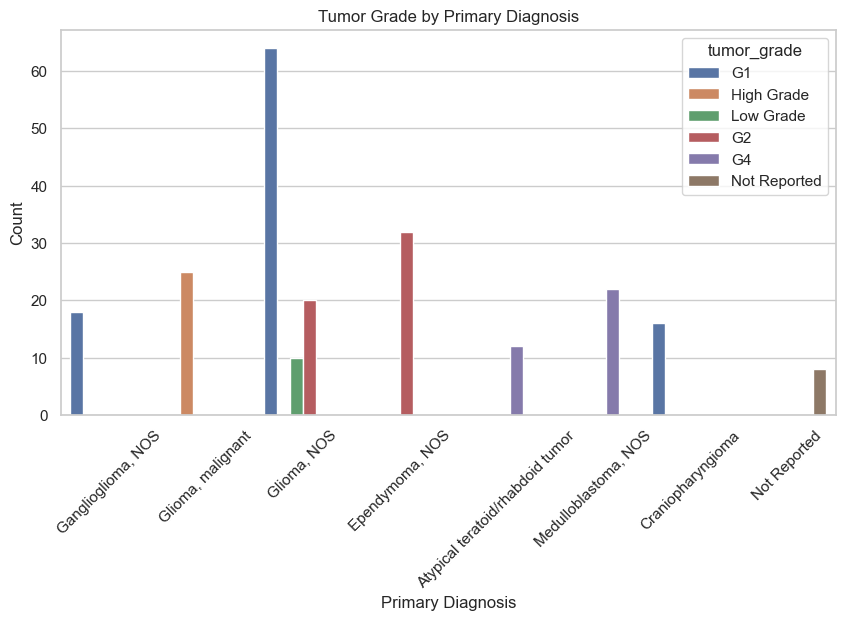

In [70]:
# make a countplot to answer research question: Does tumor grade vary by primary diagnosis?
plt.figure(figsize = (10,5))
sns.countplot(data=clinical_df, x='primary_diagnosis', hue = 'tumor_grade')
plt.xticks(rotation=45)
plt.title("Tumor Grade by Primary Diagnosis")
plt.xlabel("Primary Diagnosis")
plt.ylabel("Count")

plt.show()

Explanation: This graph shows the distribution of tumor grades and how they vary across different primary diagnoses. As shown, the x-axis is the primary diagnosis like Glioma, NOS. The legend is the tumor grade itself, such as G1, G2, G4, and high grade/low grade. The y-axis, count, is the number of patients. The graphs shows that tumor types like Glioma, NOS, have both low-grade and high-grade tumors. While others are more concentrated in a cetain category. This could mean that tumor type may be associated with how severe the tumor is.

## Research question #3, Do high-grade and low-grade tumors show different proteomic expression patterns?

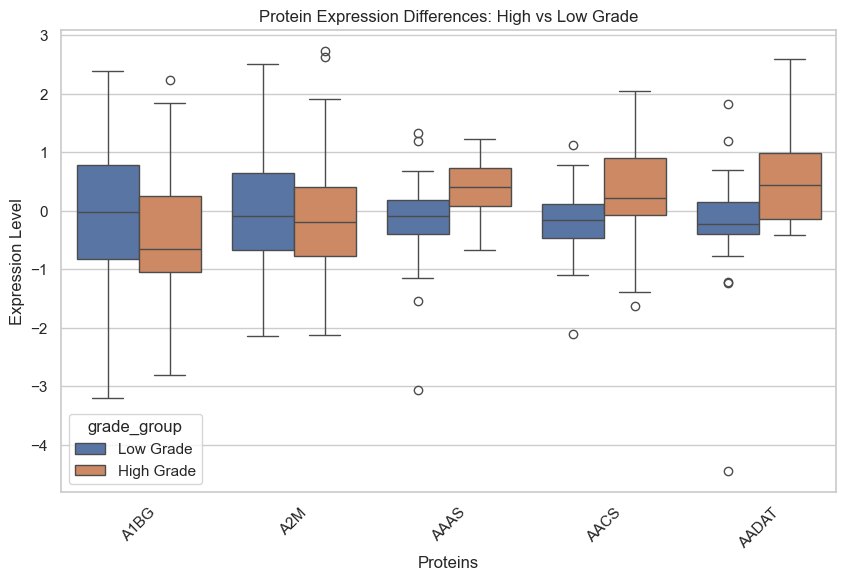

In [71]:
# selects protein columns
protein_cols= [col for col in model_df.columns
                    if col not in ['aliquot_submitter_id', 'morphology', 'primary_diagnosis',
                                   'tumor_grade', 'tumor_stage', 'grade_group']]

proteins = protein_cols[:5]

subset = model_df[proteins + ['grade_group']].melt(
    id_vars = 'grade_group',
    value_vars = proteins,
    var_name = 'Protein',
    value_name = 'Expression'
)

#create boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=subset, x='Protein', y='Expression', hue = 'grade_group')
plt.title("Protein Expression Differences: High vs Low Grade")
plt.ylabel("Expression Level")
plt.xlabel("Proteins")
plt.xticks(rotation=45)

plt.show()

Explantion: This boxplot compares the protein expression levels between low-grade and high-grade tumors. The x-axis is the proteins, A1BG, A2M etc, while the y-axis is the expression level. The legend helps indicate which tumors are low grade and which tumors are high grade. The boxplot shows that high-grade tumors tend to have high expression levels than low-grade tumors. There are a few outliars, however overall this graph could suggest that certain proteins vary by tumor grade. This helps support the idea that proteomic features can help distinguish between tumor severity. 

# **Input Preparation and Normalization/Standardization**
This is a classification problem, so the target variable does not require outlier treatment. The code below creates `X` and `y`, splits the data into training and test sets using stratification, and standardizes the numeric input features within a machine-learning pipeline.


In [72]:
# Create the feature matrix and binary target for logistic regression.
X = model_df[kept_proteins].copy()
y = model_df["grade_group"].map({"Low Grade": 0, "High Grade": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

candidate_k = sorted({min(k, len(kept_proteins)) for k in [10, 20, 40, 80, 120]})
candidate_k = [k for k in candidate_k if k > 0]

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Candidate feature counts:", candidate_k)


Training set shape: (163, 4958)
Test set shape: (55, 4958)
Candidate feature counts: [10, 20, 40, 80, 120]


# **Model Building and Training**
The baseline model is a logistic regression pipeline with median imputation, standardization, univariate feature selection, and hyperparameter tuning by cross-validation.


In [73]:
# Train and tune the logistic regression model.
logistic_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(score_func=f_classif, k=candidate_k[0])),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="liblinear",
            ),
        ),
    ]
)

param_grid = {
    "selector__k": candidate_k,
    "model__C": [0.01, 0.1, 1, 10, 100],
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
selected_mask = best_model.named_steps["selector"].get_support()
selected_features = X_train.columns[selected_mask]
feature_scores = pd.Series(
    best_model.named_steps["selector"].scores_,
    index=X_train.columns,
).sort_values(ascending=False)

print("Best cross-validated ROC-AUC:", round(grid_search.best_score_, 4))
print("Best parameters:", grid_search.best_params_)
display(feature_scores.head(15).to_frame("ANOVA_F_score"))


Best cross-validated ROC-AUC: 0.9359
Best parameters: {'model__C': 0.01, 'selector__k': 10}


,ANOVA_F_score
CTPS1,206.425641
RCC1,179.779026
XPO5,173.864427
HNRNPAB,171.098520
FEN1,166.510425
MCM2,157.048886
MCM6,154.180949
SET,152.646580
PLEC,151.364614
DNAJC9,145.520424


# **Performance Evaluation on Test Data**
This section reports the required classification metrics on the held-out test set and visualizes model performance using a confusion matrix and ROC curve.


,Metric,Value
0,Accuracy,0.8727
1,Precision,0.7500
2,Recall,0.8000
3,F1-score,0.7742
4,AUC,0.8950


              precision    recall  f1-score   support

   Low Grade       0.92      0.90      0.91        40
  High Grade       0.75      0.80      0.77        15

    accuracy                           0.87        55
   macro avg       0.84      0.85      0.84        55
weighted avg       0.88      0.87      0.87        55



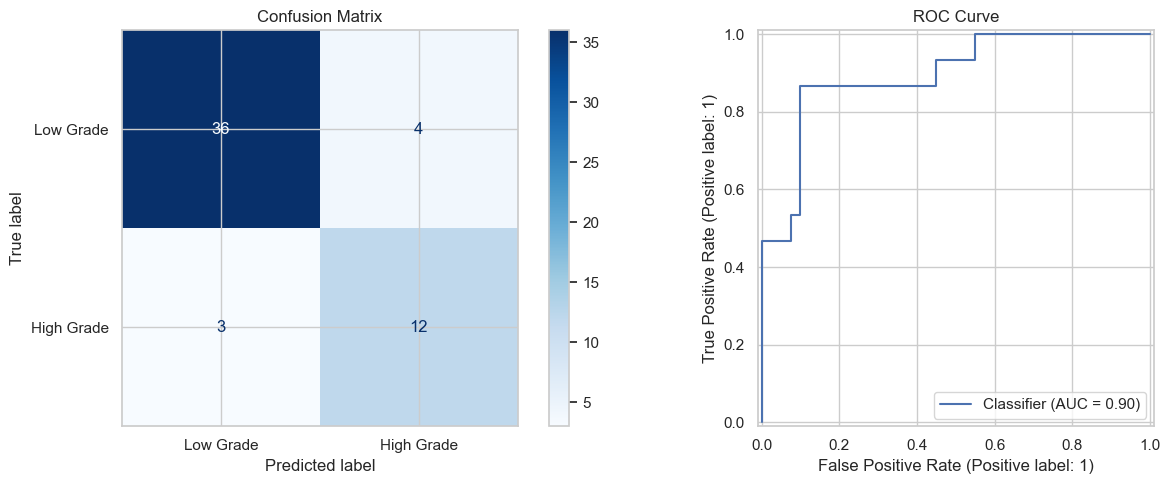

In [74]:
# Evaluate the tuned model on test data.
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

metrics_df = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
        "Value": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, zero_division=0),
            recall_score(y_test, y_pred, zero_division=0),
            f1_score(y_test, y_pred, zero_division=0),
            roc_auc_score(y_test, y_prob),
        ],
    }
)

display(metrics_df.round(4))
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Low Grade", "High Grade"],
        zero_division=0,
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Low Grade", "High Grade"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()


# **Conclusion**
The logistic regression model used standardized proteomic features from the CBTTC pediatric brain tumor study to classify tumors into low-grade and high-grade groups. Based on the held-out test results, the model showed how strongly protein expression patterns can separate tumor severity in this pediatric dataset. The selected proteins can be discussed as potentially informative biomarkers, while the main limitations are sample size, class imbalance, and study-specific generalizability.


In [75]:
# Create a short summary sentence for the abstract or conclusion.
summary_text = (
    f"Using {len(model_df)} CBTTC samples from {PDC_STUDY_ID}, the tuned logistic regression model "
    f"achieved accuracy={accuracy_score(y_test, y_pred):.3f}, "
    f"precision={precision_score(y_test, y_pred, zero_division=0):.3f}, "
    f"recall={recall_score(y_test, y_pred, zero_division=0):.3f}, "
    f"F1={f1_score(y_test, y_pred, zero_division=0):.3f}, "
    f"and ROC-AUC={roc_auc_score(y_test, y_prob):.3f} on the test set."
)

print(summary_text)
print("\nSelected protein features:")
print(list(selected_features[:15]))


Using 218 CBTTC samples from PDC000180, the tuned logistic regression model achieved accuracy=0.873, precision=0.750, recall=0.800, F1=0.774, and ROC-AUC=0.895 on the test set.

Selected protein features:
['MCM2', 'MCM6', 'RCC1', 'XPO5', 'SET', 'CTPS1', 'FEN1', 'DNAJC9', 'PLEC', 'HNRNPAB']
